# Comparação de Modelos — Baseline 2024
Consolida as métricas de todos os modelos treinados no conjunto de teste (2024).
**Métricas prioritárias:** Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

OUTPUT_MET = '../../output/metricas'
OUTPUT_PLT = '../../output/plots'
os.makedirs(OUTPUT_PLT, exist_ok=True)

LABEL_MAP = {
    'logistic_regression_baseline':          'LR',
    'logistic_regression_baseline_tuned':    'LR (tuned)',
    'lightgbm_baseline':                     'LightGBM',
    'lightgbm_baseline_tuned':               'LightGBM (tuned)',
    'xgboost_baseline':                      'XGBoost',
    'xgboost_baseline_tuned':                'XGBoost (tuned)',
    'random_forest_baseline':                'Random Forest',
    'random_forest_baseline_tuned':          'Random Forest (tuned)',
    'decision_tree_baseline':                'Decision Tree',
    'decision_tree_baseline_tuned':          'Decision Tree (tuned)',
}

## 1. Carregamento e padronização das métricas

In [2]:
rows = []
for f in sorted(os.listdir(OUTPUT_MET)):
    if not f.endswith('.parquet') or f.endswith('_predicoes.parquet'):
        continue
    base = f.replace('.parquet', '')
    if base not in LABEL_MAP:
        continue
    df = pd.read_parquet(os.path.join(OUTPUT_MET, f))

    # naive_bayes salva 'recall' em vez de 'sensibilidade'
    if 'recall' in df.columns and 'sensibilidade' not in df.columns:
        df = df.rename(columns={'recall': 'sensibilidade'})

    row = {
        'arquivo':        base,
        'modelo':         LABEL_MAP[base],
        'sensibilidade':  df['sensibilidade'].iloc[0],
        'especificidade': df['especificidade'].iloc[0],
        'auprc':          df['auprc'].iloc[0],
        'roc_auc':        df['roc_auc'].iloc[0],
        'f1':             df['f1'].iloc[0],
        'precisao':       df['precisao'].iloc[0],
        'threshold':      df['threshold'].iloc[0],
    }
    rows.append(row)

df_comp = pd.DataFrame(rows).sort_values('auprc', ascending=False).reset_index(drop=True)
print(f'{len(df_comp)} modelos carregados')

10 modelos carregados


## 2. Tabela de comparação geral

In [3]:
cols_show = ['modelo', 'sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1', 'precisao']

display(
    df_comp[cols_show]
    .round(4)
    .reset_index(drop=True)
)

,modelo,sensibilidade,especificidade,auprc,roc_auc,f1,precisao
0,XGBoost (tuned),0.7941,0.8856,0.6291,0.9175,0.3085,0.1914
1,Random Forest,0.6240,0.9834,0.6284,0.9196,0.5914,0.5620
2,Random Forest (tuned),0.4444,0.9974,0.6281,0.9041,0.5850,0.8556
3,LightGBM (tuned),0.7488,0.9201,0.6264,0.9106,0.3660,0.2422
4,LR (tuned),0.8130,0.8730,0.6248,0.9236,0.2937,0.1792
5,XGBoost,0.7505,0.9087,0.6113,0.9075,0.3390,0.2190
6,LightGBM,0.6825,0.9524,0.6104,0.9015,0.4433,0.3283
7,LR,0.7877,0.8789,0.6059,0.9162,0.2952,0.1816
8,Decision Tree (tuned),0.7347,0.8964,0.5685,0.8845,0.3080,0.1948
9,Decision Tree,0.7394,0.9015,0.5523,0.8761,0.3195,0.2038


## 3. Gráfico de barras — métricas chave

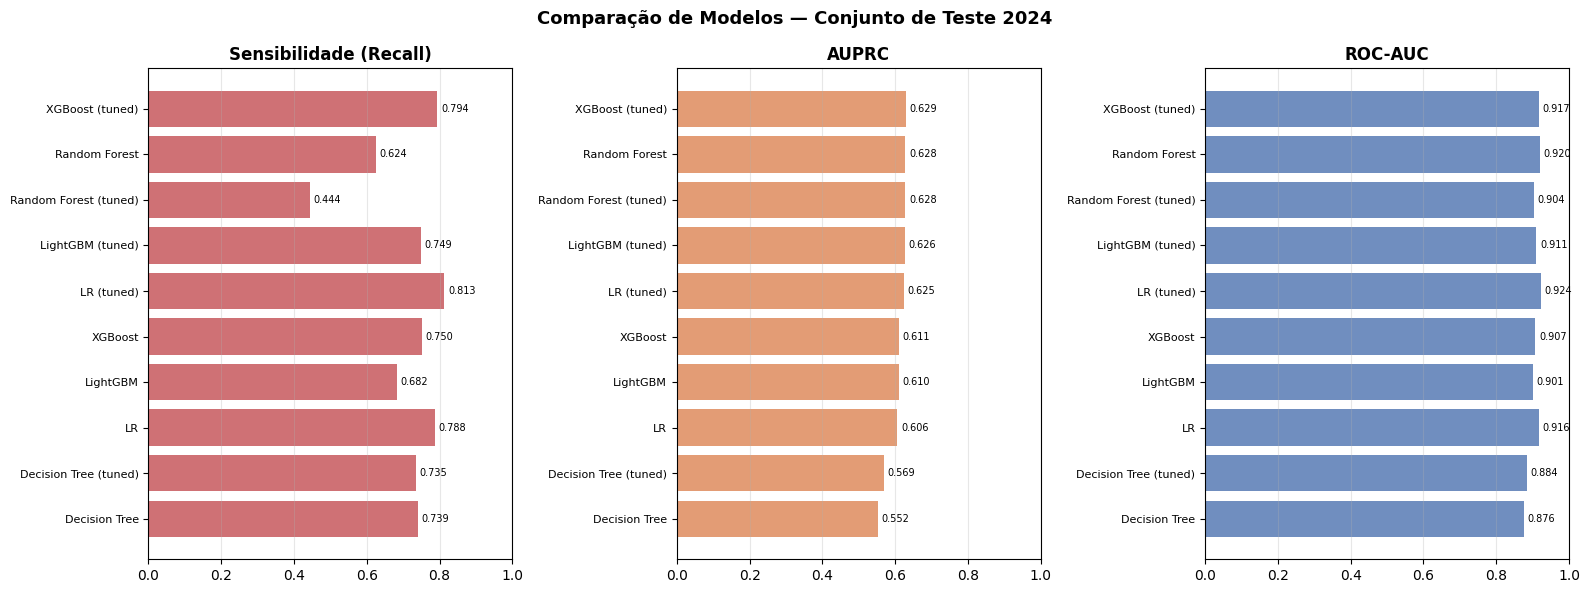

In [4]:
df_plot = df_comp.sort_values('auprc', ascending=True)
nomes   = df_plot['modelo'].tolist()
y_pos   = np.arange(len(nomes))

fig, axes = plt.subplots(1, 3, figsize=(16, max(6, len(nomes) * 0.45)))

metricas = [
    ('sensibilidade', '#C44E52', 'Sensibilidade (Recall)'),
    ('auprc',         '#DD8452', 'AUPRC'),
    ('roc_auc',       '#4C72B0', 'ROC-AUC'),
]

for ax, (col, cor, titulo) in zip(axes, metricas):
    vals = df_plot[col].tolist()
    bars = ax.barh(y_pos, vals, color=cor, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(nomes, fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=7)

plt.suptitle('Comparação de Modelos — Conjunto de Teste 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'comparacao_barras.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Curvas ROC

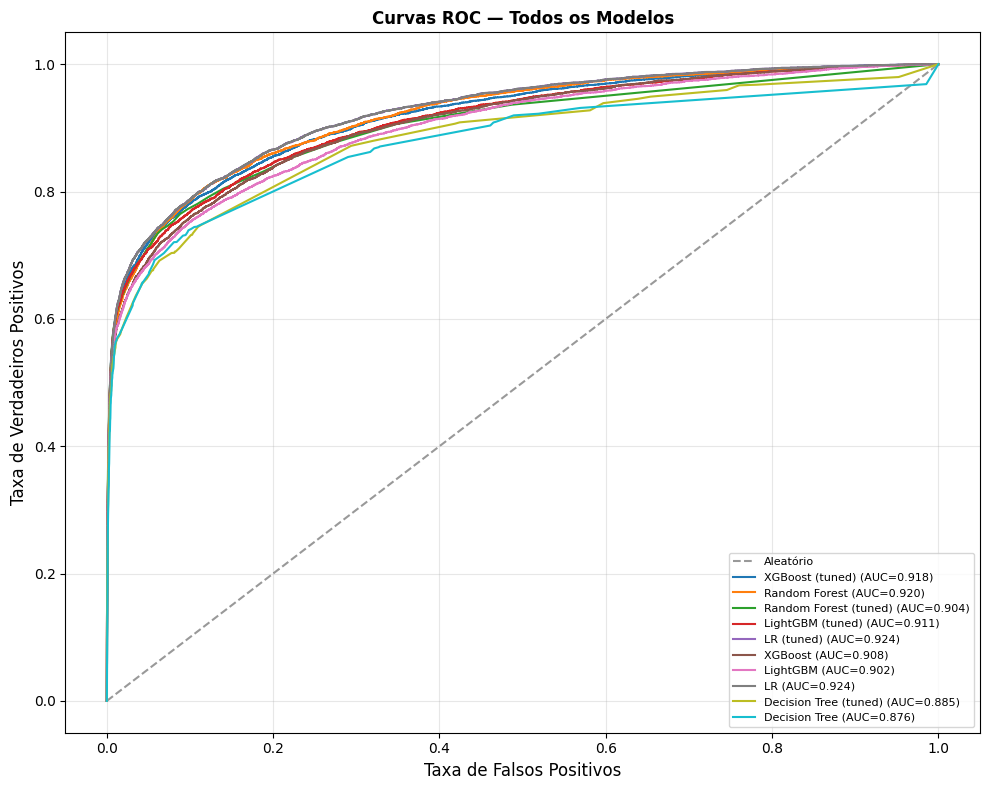

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório')

cmap   = plt.get_cmap('tab20')
colors = [cmap(i / len(df_comp)) for i in range(len(df_comp))]

for i, row in df_comp.iterrows():
    pred_path = os.path.join(OUTPUT_MET, f"{row['arquivo']}_predicoes.parquet")
    if not os.path.exists(pred_path):
        continue
    preds = pd.read_parquet(pred_path)
    fpr, tpr, _ = roc_curve(preds['y_true'], preds['y_proba'])
    roc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=1.5,
            label=f"{row['modelo']} (AUC={roc:.3f})")

ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
ax.set_title('Curvas ROC — Todos os Modelos', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'comparacao_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Curvas Precision-Recall

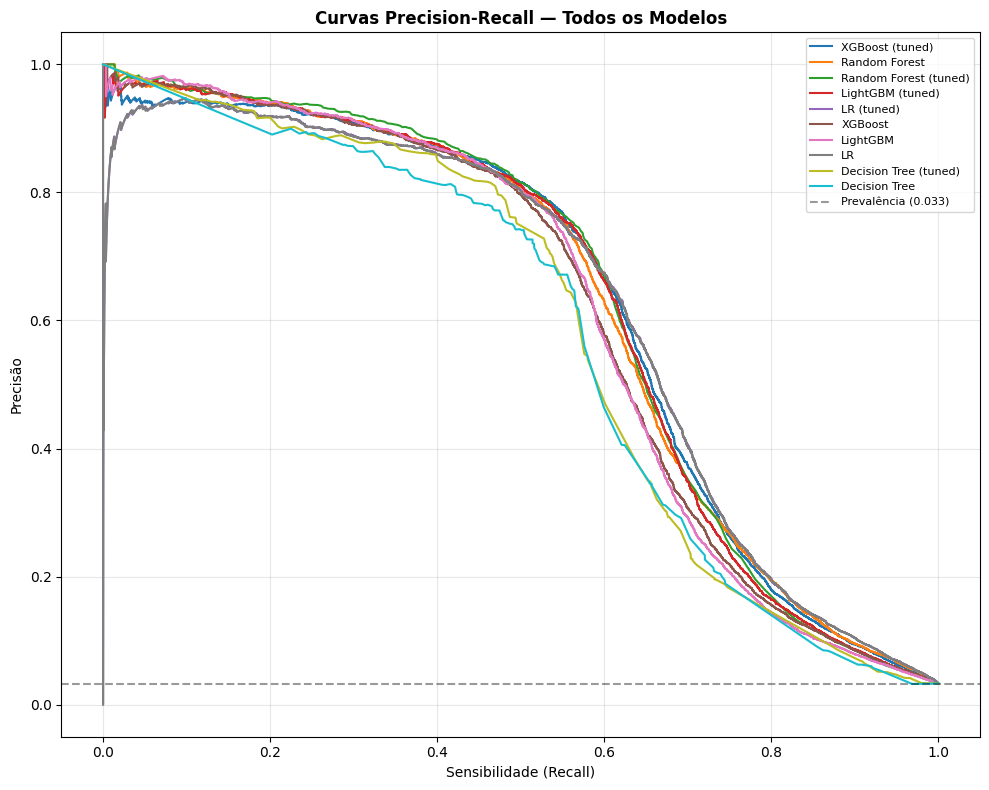

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, row in df_comp.iterrows():
    pred_path = os.path.join(OUTPUT_MET, f"{row['arquivo']}_predicoes.parquet")
    if not os.path.exists(pred_path):
        continue
    preds = pd.read_parquet(pred_path)
    prec, rec, _ = precision_recall_curve(preds['y_true'], preds['y_proba'])
    ap = auc(rec, prec)
    ax.plot(rec, prec, color=colors[i], lw=1.5,
            label=f"{row['modelo']}")

prevalencia = None
for i, row in df_comp.iterrows():
    pred_path = os.path.join(OUTPUT_MET, f"{row['arquivo']}_predicoes.parquet")
    if os.path.exists(pred_path):
        preds = pd.read_parquet(pred_path)
        prevalencia = preds['y_true'].mean()
        break
if prevalencia is not None:
    ax.axhline(prevalencia, color='k', linestyle='--', alpha=0.4,
               label=f'Prevalência ({prevalencia:.3f})')

ax.set_xlabel('Sensibilidade (Recall)', fontsize=10)
ax.set_ylabel('Precisão', fontsize=10)
ax.set_title('Curvas Precision-Recall — Todos os Modelos', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'comparacao_pr.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Análise por grupo — baseline vs tuned

In [7]:
# Agrupa por família de algoritmo para comparar baseline vs tuned
grupos = {
    'Logistic Regression': ['LR', 'LR (tuned)', 'LR + SMOTE 1:1', 'LR + SMOTE 1:5', 'LR + SMOTE 1:10'],
    'LightGBM':            ['LightGBM', 'LightGBM (tuned)'],
    'XGBoost':             ['XGBoost', 'XGBoost (tuned)'],
    'Random Forest':       ['Random Forest', 'Random Forest (tuned)'],
    'Decision Tree':       ['Decision Tree', 'Decision Tree (tuned)'],
    'Outros':              ['Naive Bayes', 'Ensemble (LR+MLP+LGBM)'],
}

print(f'{"Grupo":<22} {"Modelo":<28} {"Sensibilidade":>14} {"AUPRC":>8} {"ROC-AUC":>9}')
print('-' * 85)
for grupo, membros in grupos.items():
    subset = df_comp[df_comp['modelo'].isin(membros)]
    for _, r in subset.sort_values('auprc', ascending=False).iterrows():
        print(f'{grupo:<22} {r["modelo"]:<28} {r["sensibilidade"]:>14.4f} {r["auprc"]:>8.4f} {r["roc_auc"]:>9.4f}')
    print()

Grupo                  Modelo                        Sensibilidade    AUPRC   ROC-AUC
-------------------------------------------------------------------------------------
Logistic Regression    LR (tuned)                           0.8130   0.6248    0.9236
Logistic Regression    LR                                   0.7877   0.6059    0.9162

LightGBM               LightGBM (tuned)                     0.7488   0.6264    0.9106
LightGBM               LightGBM                             0.6825   0.6104    0.9015

XGBoost                XGBoost (tuned)                      0.7941   0.6291    0.9175
XGBoost                XGBoost                              0.7505   0.6113    0.9075

Random Forest          Random Forest                        0.6240   0.6284    0.9196
Random Forest          Random Forest (tuned)                0.4444   0.6281    0.9041

Decision Tree          Decision Tree (tuned)                0.7347   0.5685    0.8845
Decision Tree          Decision Tree              

## 7. Melhor modelo e ranking final

In [8]:
# Ranking por prioridade: sensibilidade > auprc > roc_auc
df_rank = df_comp.copy()
df_rank['rank_sens']    = df_rank['sensibilidade'].rank(ascending=False)
df_rank['rank_auprc']   = df_rank['auprc'].rank(ascending=False)
df_rank['rank_roc']     = df_rank['roc_auc'].rank(ascending=False)
# Peso: sensibilidade=3, auprc=2, roc_auc=1
df_rank['score_ponder'] = (3 * df_rank['rank_sens'] + 2 * df_rank['rank_auprc'] + df_rank['rank_roc']) / 6
df_rank = df_rank.sort_values('score_ponder')

print('=== Ranking ponderado (sensibilidade×3 + AUPRC×2 + ROC-AUC×1) ===')
print()
for pos, (_, r) in enumerate(df_rank.iterrows(), 1):
    print(f'{pos:>2}. {r["modelo"]:<30} sens={r["sensibilidade"]:.4f}  auprc={r["auprc"]:.4f}  roc={r["roc_auc"]:.4f}')

melhor = df_rank.iloc[0]
print()
print(f'>>> Modelo recomendado: {melhor["modelo"]}')
print(f'    Sensibilidade: {melhor["sensibilidade"]:.4f}')
print(f'    AUPRC:         {melhor["auprc"]:.4f}')
print(f'    ROC-AUC:       {melhor["roc_auc"]:.4f}')

=== Ranking ponderado (sensibilidade×3 + AUPRC×2 + ROC-AUC×1) ===

 1. XGBoost (tuned)                sens=0.7941  auprc=0.6291  roc=0.9175
 2. LR (tuned)                     sens=0.8130  auprc=0.6248  roc=0.9236
 3. LightGBM (tuned)               sens=0.7488  auprc=0.6264  roc=0.9106
 4. LR                             sens=0.7877  auprc=0.6059  roc=0.9162
 5. XGBoost                        sens=0.7505  auprc=0.6113  roc=0.9075
 6. Random Forest                  sens=0.6240  auprc=0.6284  roc=0.9196
 7. Random Forest (tuned)          sens=0.4444  auprc=0.6281  roc=0.9041
 8. LightGBM                       sens=0.6825  auprc=0.6104  roc=0.9015
 9. Decision Tree (tuned)          sens=0.7347  auprc=0.5685  roc=0.8845
10. Decision Tree                  sens=0.7394  auprc=0.5523  roc=0.8761

>>> Modelo recomendado: XGBoost (tuned)
    Sensibilidade: 0.7941
    AUPRC:         0.6291
    ROC-AUC:       0.9175


## 8. Salvamento

In [9]:
csv_path = os.path.join(OUTPUT_MET, 'COMPARACAO_TODOS_MODELOS.csv')
df_comp[cols_show].to_csv(csv_path, index=False)
print(f'Comparação salva: {csv_path}')

rank_path = os.path.join(OUTPUT_MET, 'RANKING_PONDERADO.csv')
df_rank[['modelo', 'sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1', 'score_ponder']].to_csv(rank_path, index=False)
print(f'Ranking salvo:    {rank_path}')

Comparação salva: ../../output/metricas/COMPARACAO_TODOS_MODELOS.csv
Ranking salvo:    ../../output/metricas/RANKING_PONDERADO.csv
